In [1]:
# Clear module cache to ensure fresh imports
import sys

# Remove cached modules related to src
modules_to_remove = [key for key in sys.modules.keys() if 'src' in key]
for module in modules_to_remove:
    del sys.modules[module]

In [2]:
from pathlib import Path
import sys
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set working directory to project root
notebook_dir = Path.cwd()
project_root = notebook_dir

# Walk up to find project root with 'src' directory
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Change to project root
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"src path exists: {(project_root / 'src').exists()}")

from src.data_pipeline import (
    SAMPLE_UNIVERSE,
    DataPreprocessor,
    YahooFinanceProvider,
)

from src.covariance import (
    compute_covariance_matrix,
    compute_correlation_matrix,
    validate_covariance_matrix,
    validate_correlation_matrix,
    rank_correlations,
    compute_average_correlation,
    compute_distance_matrix,
)

Project root: d:\PGDBA\MyNotes\SEM-3\Part-1\FRM\Project\adaptive-portfolio-risk-analytics
src path exists: True


In [3]:
symbols = list(SAMPLE_UNIVERSE)

provider = YahooFinanceProvider()

market_data = provider.get_market_data(
    symbols,
    "2020-01-01",
    "2024-12-31",
)

prices_df, _data_quality_summary = DataPreprocessor.handle_missing_values(
    market_data.prices_df
)

stage_2_outputs = (
    DataPreprocessor.build_returns_risk_outputs(
        prices_df
    )
)

log_returns_df = stage_2_outputs.log_returns_df

In [4]:
covariance_matrix_df = compute_covariance_matrix(
    log_returns_df
)

correlation_matrix_df = compute_correlation_matrix(
    log_returns_df
)

print(
    "Covariance Matrix Valid:",
    validate_covariance_matrix(
        covariance_matrix_df
    )
)

print(
    "Correlation Matrix Valid:",
    validate_correlation_matrix(
        correlation_matrix_df
    )
)

Covariance Matrix Valid: True
Correlation Matrix Valid: True


In [5]:
display(covariance_matrix_df)

display(correlation_matrix_df)

asset,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
asset,,,,,,,,,,,,,,,,,,,,,
ASIANPAINT.NS,0.000273,0.000120,7.182166e-05,0.000045,0.000064,5.118243e-06,0.000080,0.000090,0.000113,1.072305e-04,...,0.000040,0.000052,0.000108,0.000086,0.000060,0.000123,0.000078,0.000105,0.000126,0.000080
AXISBANK.NS,0.000120,0.000551,1.486200e-04,0.000063,0.000070,5.793081e-06,0.000111,0.000220,0.000102,3.576889e-04,...,0.000189,0.000118,0.000190,0.000316,0.000101,0.000167,0.000114,0.000155,0.000191,0.000130
BHARTIARTL.NS,0.000072,0.000149,3.192757e-04,0.000066,0.000061,-2.534004e-07,0.000088,0.000110,0.000064,1.417129e-04,...,0.000123,0.000093,0.000108,0.000132,0.000090,0.000109,0.000079,0.000098,0.000113,0.000082
CIPLA.NS,0.000045,0.000063,6.562781e-05,0.000300,0.000132,1.603519e-05,0.000061,0.000028,0.000046,4.429373e-05,...,0.000056,0.000053,0.000045,0.000045,0.000138,0.000075,0.000057,0.000072,0.000051,0.000065
DRREDDY.NS,0.000064,0.000070,6.131104e-05,0.000132,0.000254,1.714684e-05,0.000079,0.000043,0.000074,5.402356e-05,...,0.000066,0.000052,0.000077,0.000056,0.000114,0.000071,0.000063,0.000092,0.000080,0.000091
GOLDBEES.NS,0.000005,0.000006,-2.534004e-07,0.000016,0.000017,7.766998e-05,0.000008,-0.000006,0.000006,-7.585816e-07,...,0.000009,-0.000007,0.000006,-0.000013,0.000008,0.000002,0.000008,0.000015,0.000002,0.000012
HCLTECH.NS,0.000080,0.000111,8.817054e-05,0.000061,0.000079,7.635307e-06,0.000304,0.000089,0.000081,1.055965e-04,...,0.000122,0.000063,0.000122,0.000099,0.000083,0.000116,0.000174,0.000222,0.000113,0.000196
HDFCBANK.NS,0.000090,0.000220,1.100666e-04,0.000028,0.000043,-5.578859e-06,0.000089,0.000297,0.000064,2.230689e-04,...,0.000090,0.000088,0.000143,0.000191,0.000074,0.000109,0.000084,0.000106,0.000136,0.000095
HINDUNILVR.NS,0.000113,0.000102,6.413296e-05,0.000046,0.000074,6.200479e-06,0.000081,0.000064,0.000226,7.744255e-05,...,0.000041,0.000030,0.000090,0.000060,0.000060,0.000120,0.000074,0.000089,0.000090,0.000079


asset,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
asset,,,,,,,,,,,,,,,,,,,,,
ASIANPAINT.NS,1.000000,0.310348,0.243156,0.158823,0.242004,0.035132,0.278670,0.315850,0.456524,0.322346,...,0.099741,0.174236,0.350601,0.247899,0.226439,0.405251,0.306525,0.322727,0.435802,0.265468
AXISBANK.NS,0.310348,1.000000,0.354204,0.155569,0.186639,0.027992,0.270507,0.542538,0.290191,0.756931,...,0.329909,0.277655,0.432384,0.643368,0.269096,0.386714,0.314867,0.334720,0.465204,0.302845
BHARTIARTL.NS,0.243156,0.354204,1.000000,0.212038,0.215125,-0.001609,0.283081,0.357475,0.238786,0.394111,...,0.282267,0.285391,0.321920,0.354027,0.313169,0.334062,0.287622,0.279539,0.362269,0.251885
CIPLA.NS,0.158823,0.155569,0.212038,1.000000,0.476553,0.105040,0.202084,0.092447,0.176243,0.127070,...,0.132652,0.167915,0.138411,0.124431,0.497709,0.235639,0.212328,0.211057,0.168306,0.203838
DRREDDY.NS,0.242004,0.186639,0.215125,0.476553,1.000000,0.121981,0.283221,0.155858,0.306827,0.168310,...,0.168401,0.181088,0.258713,0.168345,0.443557,0.243060,0.258269,0.294346,0.287250,0.310810
GOLDBEES.NS,0.035132,0.027992,-0.001609,0.105040,0.121981,1.000000,0.049702,-0.036736,0.046807,-0.004277,...,0.043889,-0.043523,0.034163,-0.069801,0.056109,0.010040,0.060586,0.086570,0.013282,0.075458
HCLTECH.NS,0.278670,0.270507,0.283081,0.202084,0.283221,0.049702,1.000000,0.296423,0.309946,0.301032,...,0.286413,0.197964,0.375104,0.272231,0.294995,0.362437,0.646406,0.645836,0.371903,0.614138
HDFCBANK.NS,0.315850,0.542538,0.357475,0.092447,0.155858,-0.036736,0.296423,1.000000,0.245653,0.643286,...,0.215084,0.282287,0.443831,0.528463,0.268920,0.344416,0.317593,0.310951,0.450784,0.300734
HINDUNILVR.NS,0.456524,0.290191,0.238786,0.176243,0.306827,0.046807,0.309946,0.245653,1.000000,0.256025,...,0.111895,0.108274,0.321201,0.192077,0.250554,0.434157,0.318983,0.299646,0.343558,0.287619


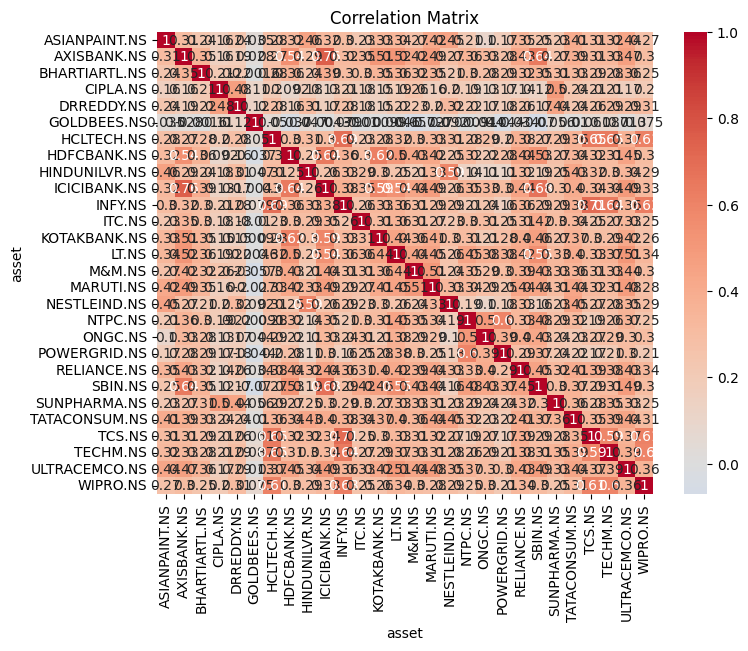

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [7]:
distance_matrix_df = compute_distance_matrix(
    correlation_matrix_df
)

display(distance_matrix_df)

asset,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
asset,,,,,,,,,,,,,,,,,,,,,
ASIANPAINT.NS,0.000000,0.587219,0.615160,0.648528,0.615628,0.694575,0.600554,0.584872,0.521285,0.582088,...,0.670917,0.642559,0.569824,0.613229,0.621917,0.545321,0.588844,0.581925,0.531130,0.606025
AXISBANK.NS,0.587219,0.000000,0.568241,0.649781,0.637715,0.697140,0.603943,0.478258,0.595739,0.348618,...,0.578831,0.600976,0.532736,0.422275,0.604526,0.553754,0.585292,0.576749,0.517106,0.590405
BHARTIARTL.NS,0.615160,0.568241,0.000000,0.627679,0.626448,0.707675,0.598715,0.566800,0.616933,0.550404,...,0.599055,0.597750,0.582271,0.568319,0.586017,0.577035,0.596816,0.600192,0.564682,0.611602
CIPLA.NS,0.648528,0.649781,0.627679,0.000000,0.511589,0.668939,0.631631,0.673629,0.641778,0.660655,...,0.658539,0.645014,0.656349,0.661653,0.501144,0.618207,0.627564,0.628070,0.644862,0.630937
DRREDDY.NS,0.615628,0.637715,0.626448,0.511589,0.000000,0.662578,0.598656,0.649670,0.588716,0.644860,...,0.644825,0.639887,0.608805,0.644847,0.527467,0.615199,0.608987,0.593992,0.596972,0.587022
GOLDBEES.NS,0.694575,0.697140,0.707675,0.668939,0.662578,0.000000,0.689311,0.719978,0.690360,0.708617,...,0.691416,0.722331,0.694923,0.731369,0.686983,0.703548,0.685352,0.675807,0.702395,0.679905
HCLTECH.NS,0.600554,0.603943,0.598715,0.631631,0.598656,0.689311,0.000000,0.593118,0.587390,0.591172,...,0.597322,0.633260,0.558971,0.603228,0.593719,0.564607,0.420472,0.420811,0.560400,0.439239
HDFCBANK.NS,0.584872,0.478258,0.566800,0.673629,0.649670,0.719978,0.593118,0.000000,0.614145,0.422323,...,0.626465,0.599046,0.527337,0.485560,0.604599,0.572531,0.584126,0.586962,0.524031,0.591298
HINDUNILVR.NS,0.521285,0.595739,0.616933,0.641778,0.588716,0.690360,0.587390,0.614145,0.000000,0.609908,...,0.666373,0.667730,0.582580,0.635580,0.612146,0.531904,0.583531,0.591758,0.572906,0.596817


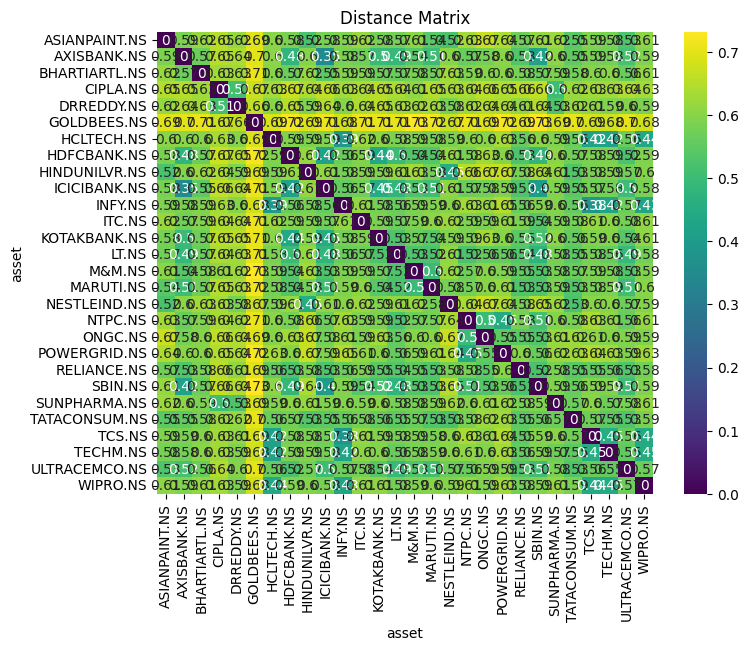

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance_matrix_df,
    annot=True,
    cmap="viridis"
)

plt.title("Distance Matrix")
plt.show()

In [9]:
correlation_rankings_df = rank_correlations(
    correlation_matrix_df
)
display(correlation_rankings_df)


,Asset A,Asset B,Correlation
0,AXISBANK.NS,ICICIBANK.NS,0.756931
1,INFY.NS,TCS.NS,0.709963
2,HCLTECH.NS,INFY.NS,0.691093
3,ICICIBANK.NS,SBIN.NS,0.675081
4,HCLTECH.NS,TCS.NS,0.646406
...,...,...,...
373,GOLDBEES.NS,MARUTI.NS,-0.027261
374,GOLDBEES.NS,HDFCBANK.NS,-0.036736
375,GOLDBEES.NS,POWERGRID.NS,-0.043523
376,GOLDBEES.NS,M&M.NS,-0.056707


In [10]:
average_correlation = compute_average_correlation(
    correlation_matrix_df
)

print(f"Average Correlation: {average_correlation:.4f}")


Average Correlation: 0.3062
